# 05 · Tuning — Random Forest con Optuna

Paralelo al tuning de XGBoost, bajo el mismo esquema de **validación cruzada
anidada (*nested CV*)**, para una comparación **tuneado-vs-tuneado justa**.

## ¿Por qué tunear Random Forest?

En el baseline (sin tunear), **Random Forest fue el mejor modelo de árboles**: mayor
AUC out-of-period (0.7627 vs 0.7540 de XGBoost) y mejor lift del decil (2.44 vs 2.29).
Tunear solo XGBoost dejaría una comparación injusta (tuneado vs sin tunear), por lo
que aquí afinamos también RF con el mismo presupuesto y protocolo, y recién entonces
se elige el modelo final.

## Mismo esquema honesto (nested CV)

El **bucle interno** (GroupKFold por vendedora **solo sobre el train-pool**) ajusta
los hiperparámetros; el **split OOT** queda **aislado** y se evalúa una sola vez. El
desbalance se maneja con `class_weight='balanced'`, calculado **dentro de cada fold**
(sin fuga del ratio de clases). RF no requiere estandarización.

## 0 · Setup, datos y split

Idéntico al tuning de XGBoost.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
Xp = X[train_mask].reset_index(drop=True); yp = y[train_mask]; gp = groups[train_mask]
print(f"train-pool (tuning) {train_mask.sum():,} | OOT (test, aislado) {test_mask.sum():,}")

train-pool (tuning) 28,311 | OOT (test, aislado) 803


## 1 · Función objetivo

GroupKFold(5) **dentro del train-pool**, predicciones out-of-fold, AUC global;
`class_weight='balanced'` por fold y poda temprana.

### Espacio de búsqueda

| Hiperparámetro | Rango | Qué controla |
|---|---|---|
| `n_estimators` | 200–800 | nº de árboles |
| `max_depth` | 4–20 | profundidad máxima |
| `max_features` | 0.1–1.0 | fracción de variables por split (decorrelaciona) |
| `min_samples_leaf` | 1–50 | tamaño mínimo de hoja (regulariza) |
| `min_samples_split` | 2–20 | mínimo para partir un nodo |
| `max_samples` | 0.5–1.0 | fracción de filas por árbol (bootstrap) |

In [2]:
GKF = GroupKFold(n_splits=5)
gkf_folds = list(GKF.split(Xp, yp, gp))


def make_rf(params):
    return RandomForestClassifier(
        **params, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)


def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 200, 800, step=50),
        max_depth=trial.suggest_int("max_depth", 4, 20),
        max_features=trial.suggest_float("max_features", 0.1, 1.0),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 50),
        min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
        max_samples=trial.suggest_float("max_samples", 0.5, 1.0),
    )
    oof = np.zeros(len(yp))
    for fold, (tr, va) in enumerate(gkf_folds):
        model = make_rf(params)
        model.fit(Xp.iloc[tr], yp[tr])
        oof[va] = model.predict_proba(Xp.iloc[va])[:, 1]
        seen = np.concatenate([va_idx for _, va_idx in gkf_folds[:fold + 1]])
        trial.report(roc_auc_score(yp[seen], oof[seen]), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return roc_auc_score(yp, oof)

## 2 · Ejecutar el estudio

`N_TRIALS = 60`, mismo presupuesto que XGBoost; TPESampler + MedianPruner.

In [3]:
N_TRIALS = 60

optuna.logging.set_verbosity(optuna.logging.WARNING)
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
pruner = optuna.pruners.MedianPruner(n_warmup_steps=5)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner,
                            study_name="rf_churn")

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

done = [t for t in study.trials if t.state.name == "COMPLETE"]
pruned = [t for t in study.trials if t.state.name == "PRUNED"]
print(f"\ntrials completados: {len(done)} | podados: {len(pruned)}")
print(f"mejor AUC validación interna (GroupKFold sobre train-pool): {study.best_value:.4f}")
print("mejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k:18s} = {v}")

  0%|          | 0/60 [00:00<?, ?it/s]


trials completados: 60 | podados: 0
mejor AUC validación interna (GroupKFold sobre train-pool): 0.7399
mejores hiperparámetros:
  n_estimators       = 350
  max_depth          = 10
  max_features       = 0.1638581982754919
  min_samples_leaf   = 28
  min_samples_split  = 6
  max_samples        = 0.590664012982737


## 3 · Diagnóstico de la búsqueda

/tmp/ipykernel_263379/3748466973.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  ax1 = plot_optimization_history(study); ax1.set_title("Historia de optimización")


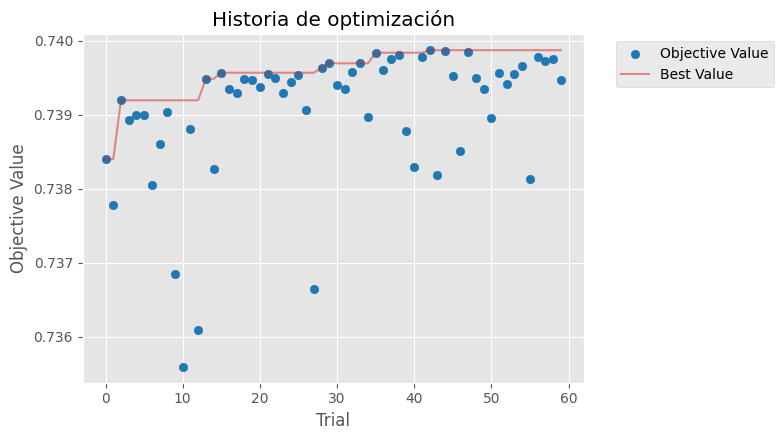

/tmp/ipykernel_263379/3748466973.py:6: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  ax2 = plot_param_importances(study); ax2.set_title("Importancia de hiperparámetros")


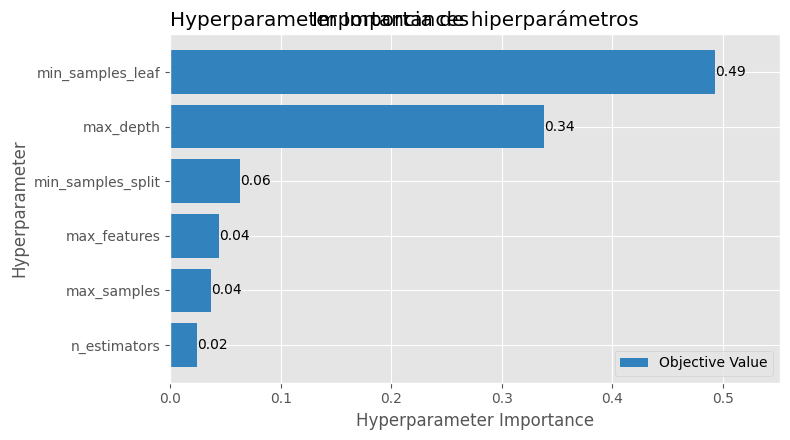

In [4]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (plot_optimization_history,
                                             plot_param_importances)
ax1 = plot_optimization_history(study); ax1.set_title("Historia de optimización")
ax1.figure.set_size_inches(8, 4.5); plt.tight_layout(); plt.show()
ax2 = plot_param_importances(study); ax2.set_title("Importancia de hiperparámetros")
ax2.figure.set_size_inches(8, 4.5); plt.tight_layout(); plt.show()

## 4 · Modelo tuneado: evaluación con los dos protocolos

In [5]:
def top_decile_lift(yt, p):
    k = max(len(yt) // 10, 1)
    return yt[np.argsort(-p)[:k]].mean() / yt.mean()


def eval_model():
    oof = np.zeros(len(yp))
    for tr, va in gkf_folds:
        m = make_rf(study.best_params); m.fit(Xp.iloc[tr], yp[tr])
        oof[va] = m.predict_proba(Xp.iloc[va])[:, 1]
    cv_auc = roc_auc_score(yp, oof); cv_ap = average_precision_score(yp, oof)
    cv_lift = top_decile_lift(yp, oof)
    model = make_rf(study.best_params); model.fit(X[train_mask], y[train_mask])
    p = model.predict_proba(X[test_mask])[:, 1]; yt = y[test_mask]; pr = (p >= 0.5).astype(int)
    dft = df[test_mask].copy(); dft["p"] = p
    aucs = [roc_auc_score(g["churn"], g["p"]) for _, g in
            dft.groupby(dft["mes_obs"].dt.strftime("%Y-%m")) if g["churn"].nunique() > 1]
    return model, {
        "cv_AUC": cv_auc, "cv_PRAUC": cv_ap, "cv_lift10": cv_lift,
        "oot_AUC": roc_auc_score(yt, p), "oot_AUCstd": np.std(aucs),
        "oot_F1": f1_score(yt, pr, zero_division=0),
        "oot_prec": precision_score(yt, pr, zero_division=0),
        "oot_rec": recall_score(yt, pr), "oot_lift10": top_decile_lift(yt, p),
    }


tuned, metrics_tuned = eval_model()
pd.Series(metrics_tuned).round(4)

cv_AUC        0.7399
cv_PRAUC      0.5302
cv_lift10     1.9932
oot_AUC       0.7590
oot_AUCstd    0.0214
oot_F1        0.5435
oot_prec      0.4334
oot_rec       0.7286
oot_lift10    2.3421
dtype: float64

## 5 · Comparación: RF baseline vs tuneado

In [6]:
baseline_rf = {"oot_AUC": 0.7627, "oot_AUCstd": 0.0233, "oot_F1": 0.5509,
               "oot_prec": 0.4361, "oot_rec": 0.7476, "oot_lift10": 2.4377}
tuned_oot = {k: metrics_tuned[k] for k in baseline_rf}
cmp = pd.DataFrame({"RF baseline": baseline_rf, "RF tuneado": tuned_oot}).T
cmp.loc["Δ"] = cmp.loc["RF tuneado"] - cmp.loc["RF baseline"]
print("Comparación en OOT (test externo, NO visto durante el tuning):")
print(cmp.round(4).to_string())
print(f"\nValidación interna (GroupKFold train-pool): AUC {metrics_tuned['cv_AUC']:.4f}"
      f" | PR-AUC {metrics_tuned['cv_PRAUC']:.4f} | lift decil {metrics_tuned['cv_lift10']:.4f}")

Comparación en OOT (test externo, NO visto durante el tuning):
             oot_AUC  oot_AUCstd  oot_F1  oot_prec  oot_rec  oot_lift10
RF baseline   0.7627      0.0233  0.5509    0.4361   0.7476      2.4377
RF tuneado    0.7590      0.0214  0.5435    0.4334   0.7286      2.3421
Δ            -0.0037     -0.0019 -0.0074   -0.0027  -0.0190     -0.0956

Validación interna (GroupKFold train-pool): AUC 0.7399 | PR-AUC 0.5302 | lift decil 1.9932


## 6 · Persistir

In [7]:
import joblib
params_path = base / "05_modelling" / "rf_best_params.json"
with open(params_path, "w") as f:
    json.dump({"best_params": study.best_params,
               "best_value_cv_auc_trainpool": study.best_value,
               "oot_auc": metrics_tuned["oot_AUC"],
               "n_trials": N_TRIALS, "random_state": RANDOM_STATE}, f, indent=2)
print(f"hiperparámetros → {params_path}")
models_dir = base / "models"; models_dir.mkdir(exist_ok=True)
model_path = models_dir / "rf_tuned.joblib"
joblib.dump(tuned, model_path)
print(f"modelo → {model_path}")

hiperparámetros → /home/carlos/projects/glamour/customer-churn-prediction/05_modelling/rf_best_params.json
modelo → /home/carlos/projects/glamour/customer-churn-prediction/models/rf_tuned.joblib


## 7 · Síntesis

_(Completar tras ejecutar.)_

- AUC OOT del RF tuneado vs. baseline (0.7627) y vs. XGBoost tuneado (0.7648).
- El **modelo final** se decide comparando ambos tuneados en OOT (AUC + recall +
  lift de decil), recordando el techo de señal (~0.77) y la variabilidad mensual.